# Homework — Extended EDA & data pipeline (MILK10k)

Scales the Session 1–2 single-image work up to the whole dataset and builds the
reusable code the project will call from here on. All logic lives in the
`src/milk10k/` package — this notebook only drives it and records the findings.

| Part | Module | What it does |
|---|---|---|
| 1 Metadata ↔ target | `milk10k.stats` | field inventory, chi-square / Cramér's V, Kruskal–Wallis / ε² |
| 2 Colour & histograms | `milk10k.color` | class-average histograms, per-image colour statistics |
| 3 Preprocessing | `milk10k.preprocess` | `preprocess_image`, `preprocess_batch` |
| 4 Data loader | `milk10k.loader` | `MILK10kLoader` → batches of (image, label) |
| 5 Visualiser | `milk10k.viz` | image grids, class balance, batch summaries |

Figures are written to `reports/figures/` and the written report is `exercises/exercise_3.pdf`.

In [ ]:
import sys, time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import milk10k
from milk10k import stats, color, viz
from milk10k import PreprocessConfig, preprocess_image, preprocess_batch, MILK10kLoader

viz.apply_style()
pd.set_option("display.width", 160); pd.set_option("display.max_columns", 30)
FIG = milk10k.FIG_DIR; FIG.mkdir(parents=True, exist_ok=True)
PROC = milk10k.PROJECT_ROOT / "data" / "processed"; PROC.mkdir(parents=True, exist_ok=True)

images = milk10k.load_images_table()          # one row per image (10,480)
lesions = stats.lesion_table_for_stats(images) # one row per lesion (5,240) - patient/lesion fields
print("images:", images.shape, "| lesions:", lesions.shape, "| image dir exists:", milk10k.IMAGE_DIR.exists())

images: (10480, 32) | lesions: (5240, 21) | image dir exists: True


## Part 1 — Metadata analysis: correlation with the target

**Target.** The 11-class top-level diagnosis `label` (from `training_gt.csv`), as in Milestone 1.

**Unit of analysis.** Every lesion has exactly two images and every patient/lesion field is identical on both,
so lesion-level fields are tested on the 5,240-row lesion table — testing them on the 10,480-row image table
would count each lesion twice and halve every p-value for free. Only fields that genuinely differ between the
two images of a lesion (`image_type`, `image_manipulation`, the `MONET_*` scores) are tested at image level.

### 1.1 Field inventory — type, level, missingness, caveats

In [ ]:
fields = stats.describe_fields(images)
fields.to_csv(PROC / "hw_field_inventory.csv", index=False)
fields.style.hide(axis="index")

field,kind,level,n_unique,pct_missing,note
attribution,constant,lesion,1,0.000000,
copyright_license,constant,lesion,1,0.000000,
age_approx,numeric,lesion,17,0.400000,
anatom_site_general,categorical,lesion,4,37.300000,coarse anatomical site; the 37% 'missing' rows are exactly the trunk lesions
anatom_site_special,categorical,lesion,2,98.000000,"acral / oral-genital flag, set for only 2% of lesions"
concomitant_biopsy,boolean,lesion,2,0.000000,BIAS RISK: whether a biopsy was taken - a decision made *because of* the suspected diagnosis
diagnosis_1,categorical,lesion,3,0.000000,LEAKAGE: the target's own benign/malignant level
diagnosis_2,categorical,lesion,19,0.000000,LEAKAGE: the target's own second hierarchy level
diagnosis_3,categorical,lesion,27,1.500000,LEAKAGE: the target's own third hierarchy level
diagnosis_4,categorical,lesion,15,85.500000,LEAKAGE: the target's own fourth hierarchy level


**Reading the inventory.** 26 non-id, non-target columns. `attribution` / `copyright_license` are constants; `isic_id`, `lesion_id`, `path` are identifiers. There is **no free-text field** and — despite the paper describing five collection centres — **no field that records the centre or device**: `site` is a fine-grained *anatomical* site (8 levels, 0.6 % missing), and `anatom_site_general` is its coarser version whose 37 % "missing" values are exactly the trunk lesions (missing-not-at-random, so imputing it as `unknown` would silently encode *trunk*). `anatom_site_special` (2 % filled) and `invasion_thickness_interval` (5 %) are sparse flags. `diagnosis_1..4`, `diagnosis_full`, `melanocytic` and `invasion_thickness_interval` are *derived from the label* and are excluded from the tests below. The seven `MONET_*` columns are per-image scores produced by a vision-language model, i.e. image features, not clinical metadata.

### 1.2–1.3 Association with the target

* **Categorical / boolean field** → Pearson **chi-square** test of independence + bias-corrected **Cramér's V** (0–1 effect size).
* **Numeric / ordinal field** → **Kruskal–Wallis H** (rank-based one-way ANOVA) + **ε²** (share of rank variance explained).

Why these: with n = 5,240 almost any field is "significant", so the *effect size* is what we rank on, and Cramér's V /
ε² are the standard effect sizes for those two tests. Kruskal–Wallis is used instead of the classic F-test because
`age_approx` is 5-year-binned and skewed, the MONET scores are bounded 0–1 and far from normal, and class sizes range from
9 to 2,522 — conditions under which the F-test's normality / equal-variance assumptions fail while the rank test stays valid.
Because V is on a correlation scale and ε² on a squared scale, the ranking uses **V or √ε²** so both families are comparable.
Fields that *are* the label (`diagnosis_1..4`, `diagnosis_full`, `melanocytic`, `invasion_thickness_interval`) are excluded from the tests and flagged as leakage.

In [ ]:
summary, results = stats.association_table(lesions, images)
summary.to_csv(PROC / "hw_association_summary.csv", index=False)
show = summary[["field", "kind", "level", "pct_missing", "test", "n", "statistic", "dof", "p_value",
                "effect_name", "effect_size", "effect_r", "note"]].copy()
show["p_value"] = show["p_value"].map(lambda p: f"{p:.1e}")
show.round(3).style.hide(axis="index")

field,kind,level,pct_missing,test,n,statistic,dof,p_value,effect_name,effect_size,effect_r,note
anatom_site_special,categorical,lesion,98.000000,chi-square,103,55.140000,5,1.2e-10,Cramér's V,0.701000,0.701000,"acral / oral-genital flag, set for only 2% of lesions"
MONET_pigmented,numeric,image,0.000000,Kruskal-Wallis,10480,4114.928000,10,0.0e+00,epsilon²,0.392000,0.626000,"derived from the image by a vision-language model, not clinical metadata"
MONET_erythema,numeric,image,0.000000,Kruskal-Wallis,10480,2502.957000,10,0.0e+00,epsilon²,0.238000,0.488000,"derived from the image by a vision-language model, not clinical metadata"
age_approx,numeric,lesion,0.400000,Kruskal-Wallis,5220,1054.453000,10,3.5e-220,epsilon²,0.201000,0.448000,
MONET_skin_markings_pen_ink_purple_pen,numeric,image,0.000000,Kruskal-Wallis,10480,1610.516000,10,0.0e+00,epsilon²,0.153000,0.391000,"derived from the image by a vision-language model, not clinical metadata"
MONET_vasculature_vessels,numeric,image,0.000000,Kruskal-Wallis,10480,1203.211000,10,2.9e-252,epsilon²,0.114000,0.338000,"derived from the image by a vision-language model, not clinical metadata"
diagnosis_confirm_type,categorical,lesion,0.000000,chi-square,5240,514.125000,10,4.2e-104,Cramér's V,0.310000,0.310000,BIAS RISK: biopsied vs clinically assessed - benign lesions are the non-biopsied ones
concomitant_biopsy,boolean,lesion,0.000000,chi-square,5240,514.125000,10,4.2e-104,Cramér's V,0.310000,0.310000,BIAS RISK: whether a biopsy was taken - a decision made *because of* the suspected diagnosis
MONET_ulceration_crust,numeric,image,0.000000,Kruskal-Wallis,10480,1009.700000,10,1.5e-210,epsilon²,0.095000,0.309000,"derived from the image by a vision-language model, not clinical metadata"
MONET_gel_water_drop_fluid_dermoscopy_liquid,numeric,image,0.000000,Kruskal-Wallis,10480,812.791000,10,3.7e-168,epsilon²,0.077000,0.277000,"derived from the image by a vision-language model, not clinical metadata"


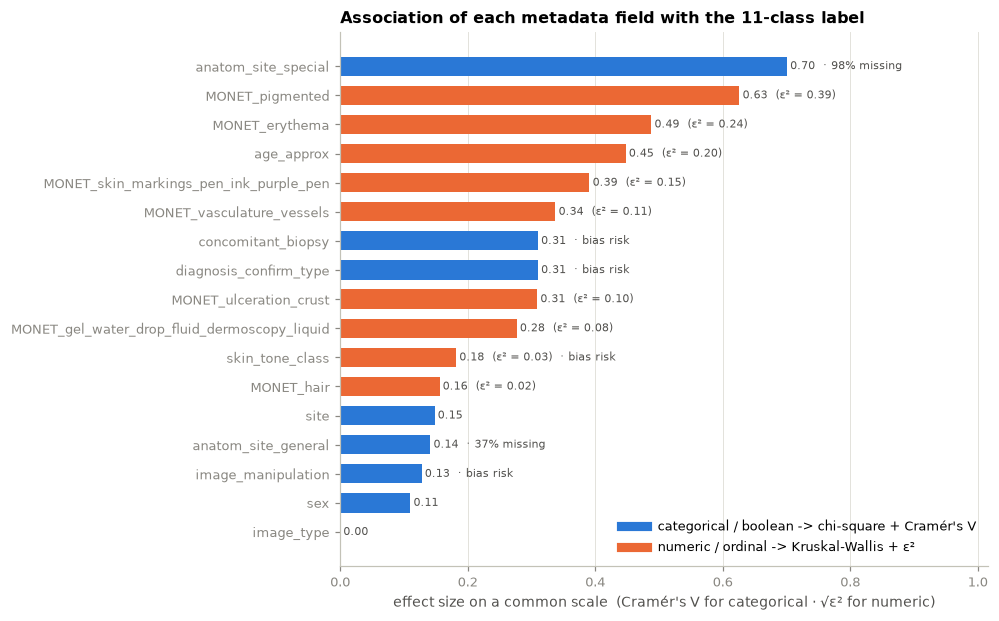

In [ ]:
viz.plot_association_ranking(summary, save=FIG / "09_field_association_ranking.png");

### Categorical fields — how the class distribution shifts within each category
Each heatmap row is one category; the cell is P(class | category) with the row count on the left.

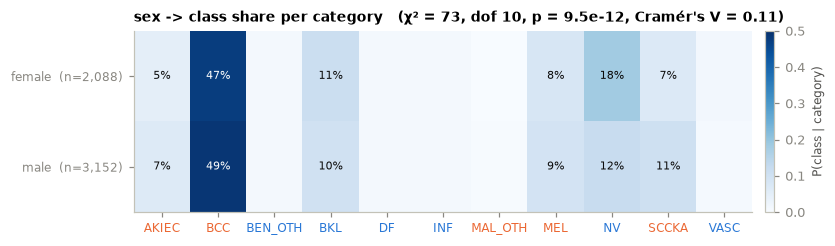

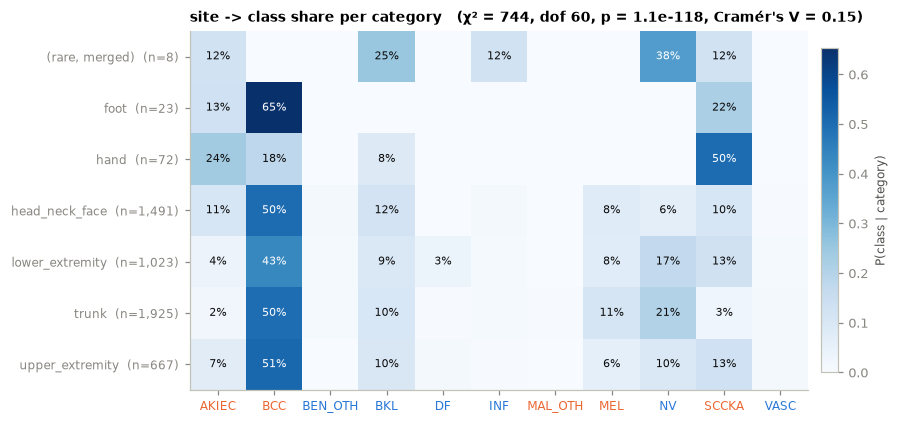

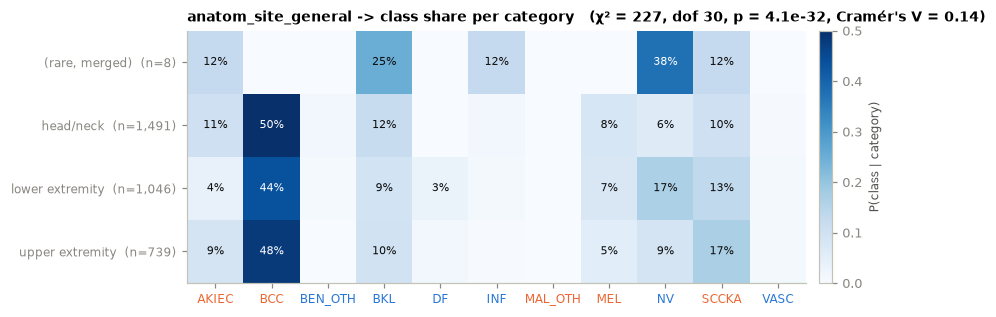

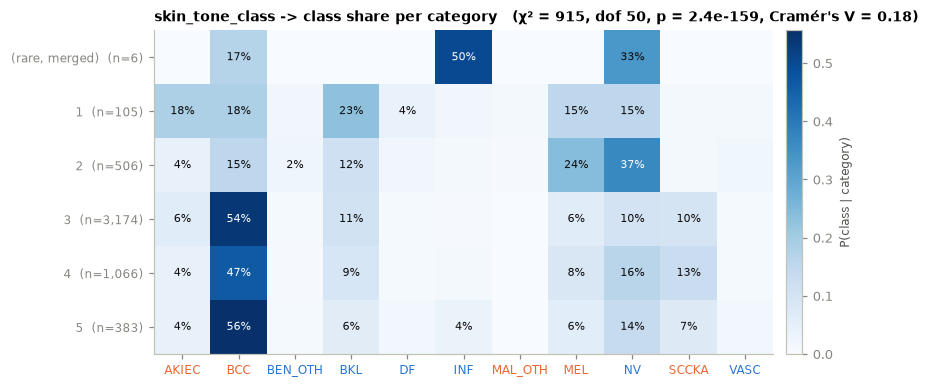

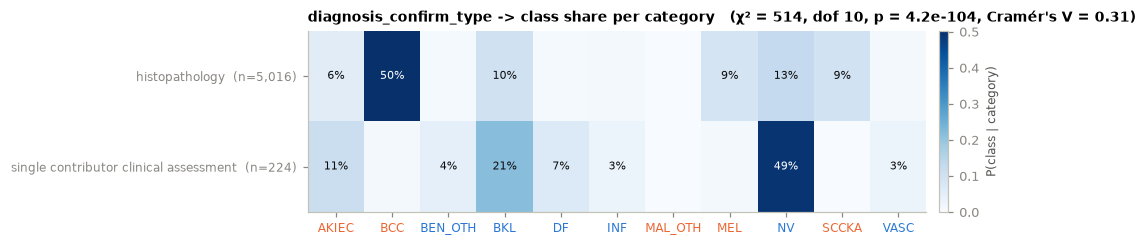

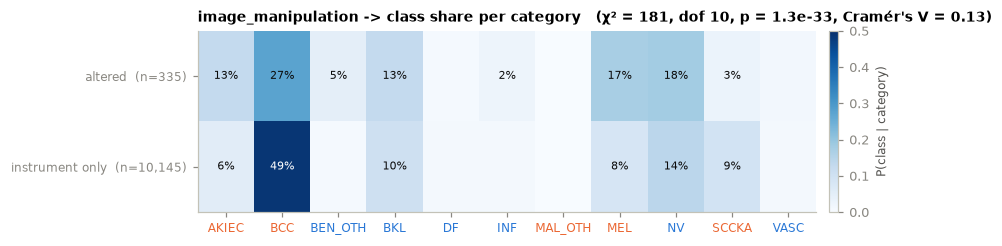

In [ ]:
for f in ["sex", "site", "anatom_site_general", "skin_tone_class", "diagnosis_confirm_type", "image_manipulation"]:
    table = images if f in stats.IMAGE_LEVEL_FIELDS else lesions
    r = stats.categorical_vs_target(table, f, min_count=10)
    viz.plot_categorical_association(r, save=FIG / f"09_cat_{f}.png")
    plt.show()

### Numeric fields — distribution per class
Boxplots per class (whiskers = 1.5 IQR, outliers hidden), coloured benign / malignant.

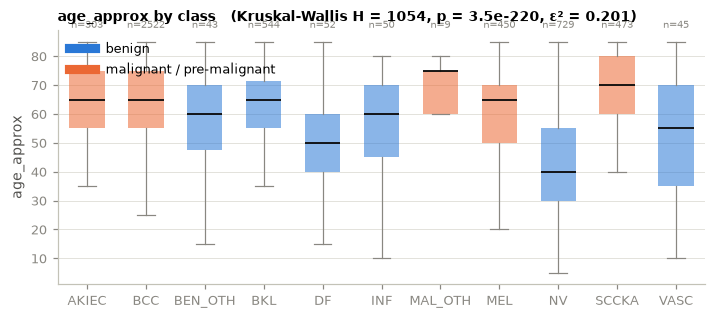

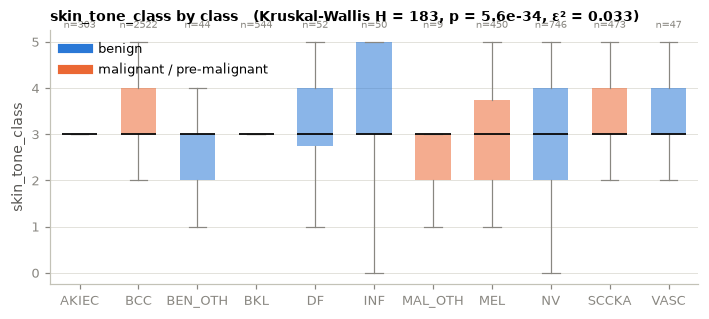

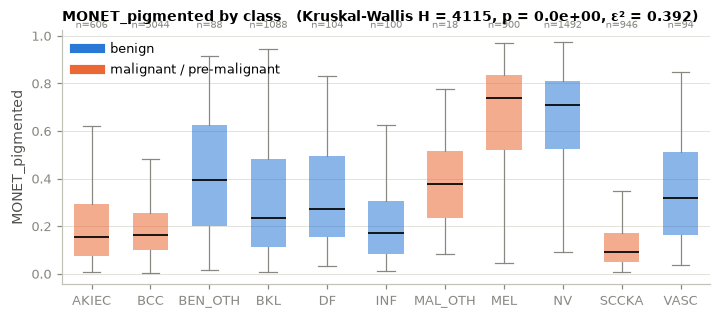

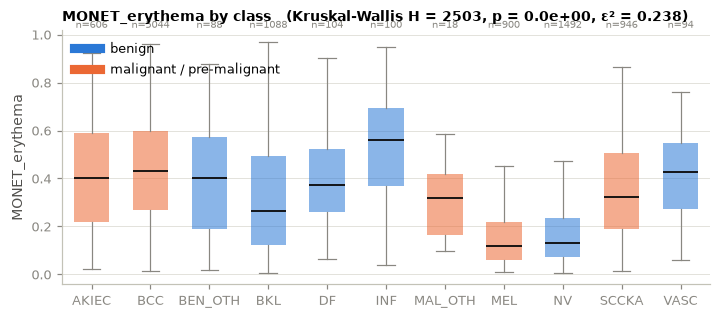

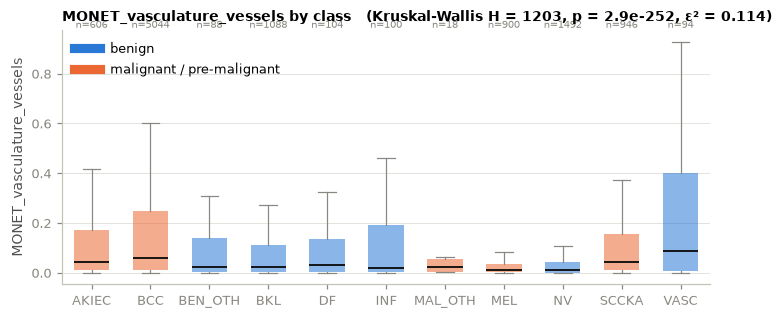

,n,mean,median,std
label,,,,
AKIEC,303,65.9,65.0,12.3
BCC,2522,64.9,65.0,11.8
BEN_OTH,43,56.6,60.0,19.4
BKL,544,63.7,65.0,12.4
DF,52,50.4,50.0,14.4
INF,50,55.6,60.0,17.3
MAL_OTH,9,66.7,75.0,13.9
MEL,450,61.8,65.0,14.8
NV,729,42.0,40.0,17.7


In [ ]:
for f, table in [("age_approx", lesions), ("skin_tone_class", lesions),
                 ("MONET_pigmented", images), ("MONET_erythema", images), ("MONET_vasculature_vessels", images)]:
    viz.plot_numeric_by_class(table, f, results[f], save=FIG / f"09_num_{f}.png")
    plt.show()
results["age_approx"]["per_class"].round(1)

### 1.4 Summary — which fields matter, which don't, and which are traps

**Most associated with the label (usable):**
1. **`age_approx`** — H = 1054, ε² = 0.20 (√ε² = 0.45). Median age is **40 for NV** vs **65–70 for BCC / AKIEC / SCCKA**; DF and VASC sit in between (50–55). This is real clinical prior knowledge (keratinocyte cancers are diseases of older, sun-damaged skin) and a legitimate auxiliary model input.
2. **`MONET_pigmented`** (ε² = 0.39) and **`MONET_erythema`** (ε² = 0.24) — the strongest signals of all, but they are *image-derived* scores from a pretrained model, so they belong with the image features, not the metadata.
3. **`skin_tone_class`** (ε² = 0.03, V = 0.18 as categorical) and **`site`** (V = 0.15): tone 2 lesions are 37 % NV / 24 % MEL whereas tones 3–5 are ~50 % BCC; hands are 50 % SCCKA and feet 65 % BCC.

**Least useful:** `image_type` (V = 0.00 — every lesion has one of each, by construction), `MONET_hair` (ε² = 0.02), **`sex`** (V = 0.11: 60 % male overall, 70 % in SCCKA, 68 % in AKIEC, but 50 % in NV and 45 % in VASC — real but weak), and `anatom_site_special` (V = 0.70 looks huge but n = 103 and 98 % missing — unusable).

**Bias / leakage flags:**
* `diagnosis_1..4`, `diagnosis_full`, `melanocytic`, `invasion_thickness_interval` — literally the label or a function of it (`melanocytic` is `True` only for NV / MEL rows and NaN elsewhere).
* **`diagnosis_confirm_type` ≡ `concomitant_biopsy`** (identical χ² = 514, V = 0.31): whether a lesion was biopsied is a decision the clinician made *because of* the suspected diagnosis, and every non-biopsied lesion is benign. A model given this column learns the clinician's workflow, not the lesion.
* **`image_manipulation`** (V = 0.13): 327 of the 335 "altered" images are clinical photos — an acquisition artefact that happens to correlate with class.
* **`skin_tone_class`** and **`site`**: legitimate priors, but skin tone is also a proxy for which country / centre contributed the lesion (only 2 % of lesions are tone 0–1, 61 % are tone 3), so a model can learn *centre* through it. Any use of these should be audited with per-tone / per-site metrics.

## Part 2 — Colour and histogram analysis across the dataset

**Sample.** 30 images per class *per modality* (seed 42; MAL_OTH has only 9 lesions so keeps all 9). Modalities are
never pooled: the dermoscopic / clinical split dominates colour far more than diagnosis does, so a fair class
comparison has to be made within one modality. Statistics are computed on the raw 0–255 image (256×256 centre crop,
no normalisation) through the same decode path as the preprocessing pipeline.

In [ ]:
sample = color.sample_per_class(images, n_per_class=30, seed=42)
t0 = time.time()
ctab = color.compute_color_table(sample, verbose=False)
print(f"{len(ctab)} images in {time.time()-t0:.1f}s, skipped: {ctab.attrs['skipped']}")
ctab.drop(columns=["gray_hist", "rgb_hist"]).to_csv(PROC / "hw_color_stats_sample.csv", index=False)
sample.groupby(["image_type", "label"]).size().unstack()

618 images in 4.1s, skipped: []


label,AKIEC,BCC,BEN_OTH,BKL,DF,INF,MAL_OTH,MEL,NV,SCCKA,VASC
image_type,,,,,,,,,,,
clinical,30,30,30,30,30,30,9,30,30,30,30
dermoscopic,30,30,30,30,30,30,9,30,30,30,30


### 5. Class-average histograms (grayscale + R, G, B)
Left: all classes overlaid (benign = blues, dashed; malignant = oranges, solid). Below: one panel per class with the
all-class mean dotted, which is the readable version of the same information.

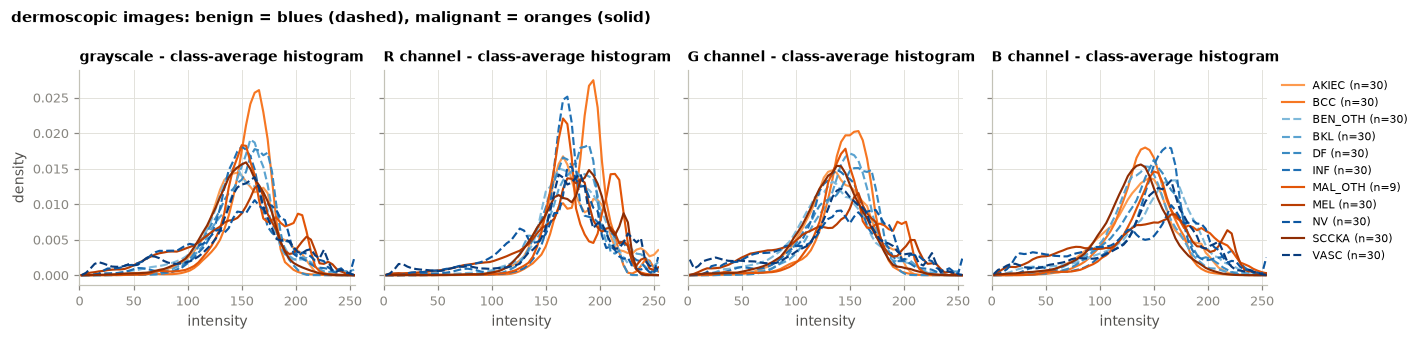

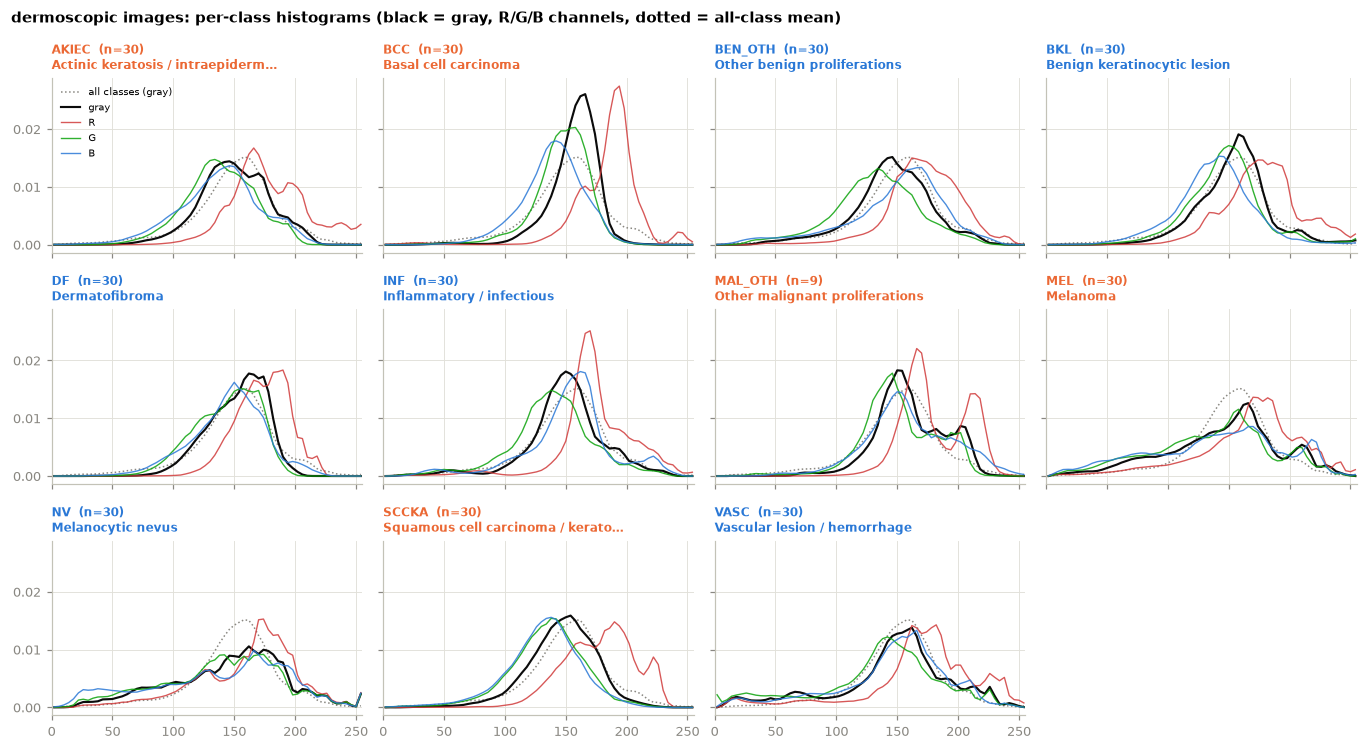

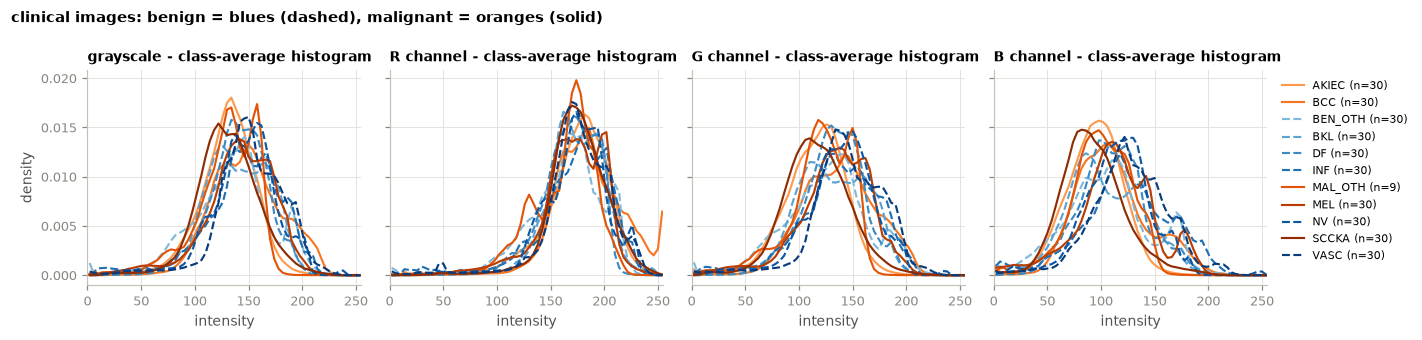

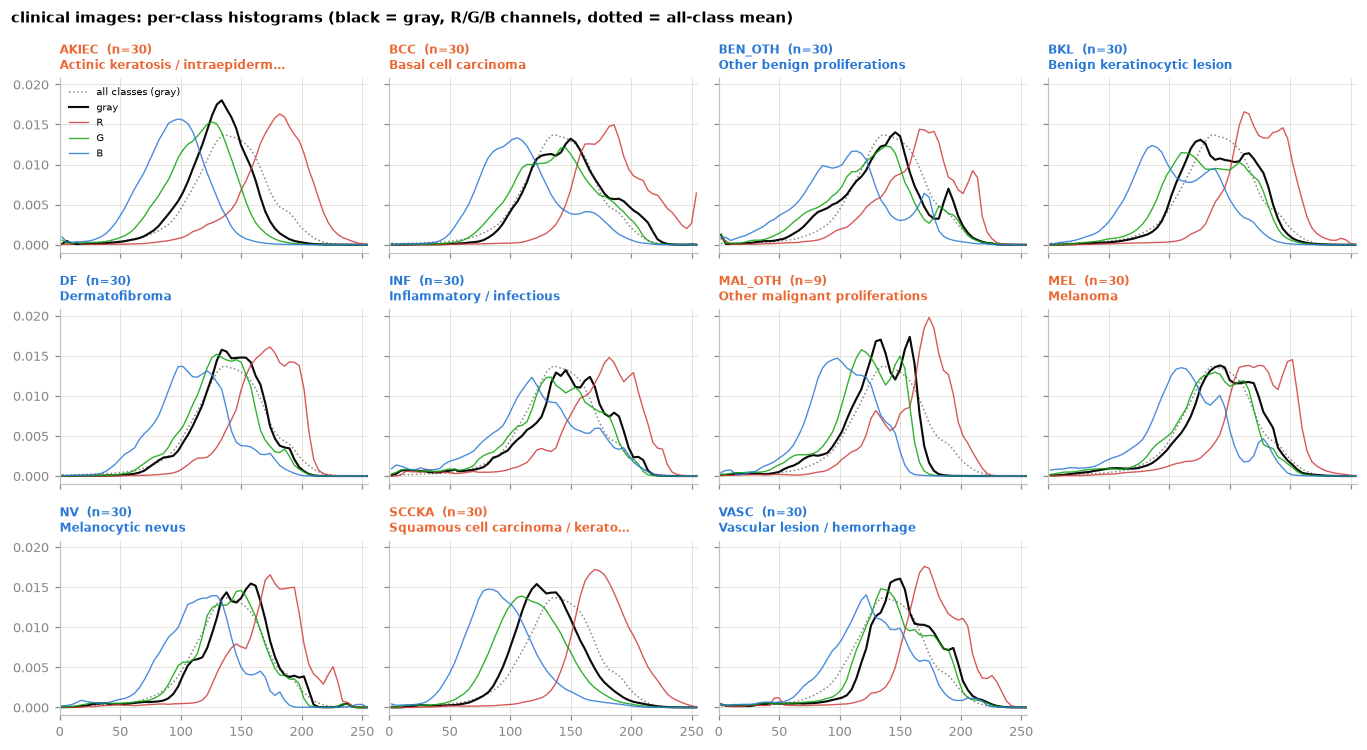

In [ ]:
centers = color.bin_centers()
hists = {}
for mod in ["dermoscopic", "clinical"]:
    sub = ctab[ctab.image_type == mod]
    hists[mod] = color.class_histograms(sub)
    viz.plot_class_histograms(hists[mod], centers, modality=mod, save=FIG / f"10_hist_overlay_{mod}.png"); plt.show()
    viz.plot_class_histogram_grid(hists[mod], centers, modality=mod, save=FIG / f"10_hist_grid_{mod}.png"); plt.show()

### 6. Per-image colour summary statistics, aggregated per class

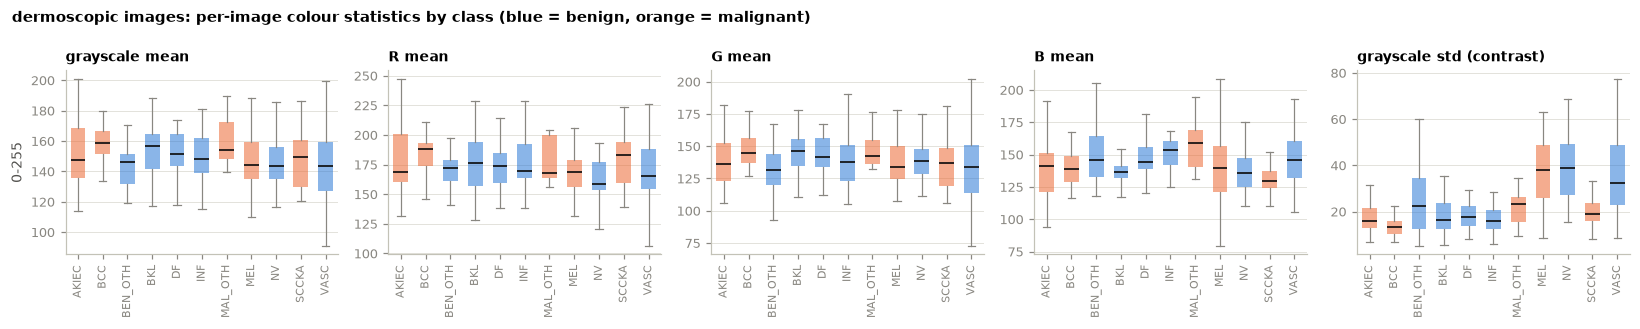

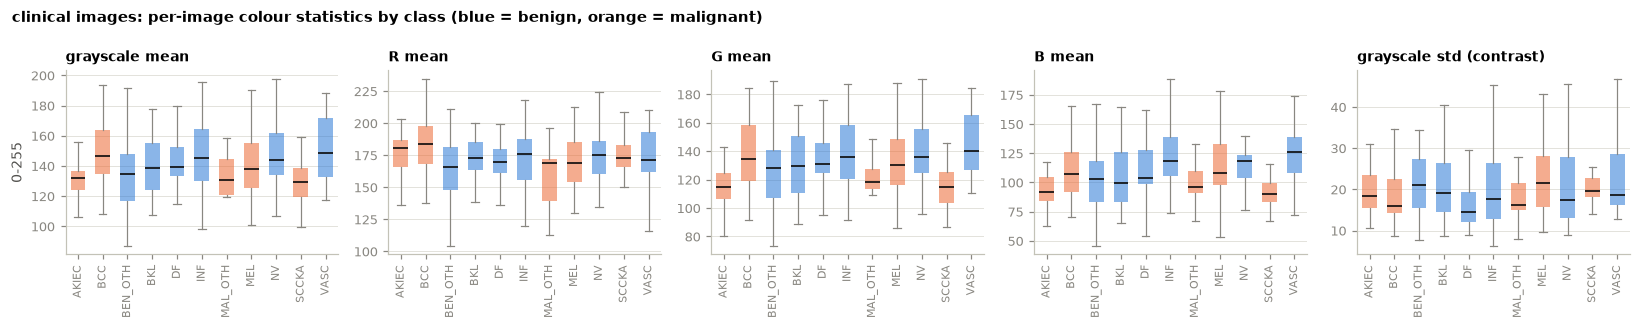

dermoscopic — per-class mean of the per-image statistics (± std across images)


,n_images,gray_mean_mean,gray_mean_std,gray_std_mean,r_mean_mean,g_mean_mean,b_mean_mean
label,,,,,,,
AKIEC,30,150.4,21.7,17.1,178.9,138.3,137.8
BCC,30,156.7,13.1,14.5,184.2,146.2,138.9
BEN_OTH,30,145.7,16.8,24.2,171.8,132.0,147.7
BKL,30,154.6,20.0,19.2,177.6,146.2,137.4
DF,30,152.3,14.3,18.3,173.2,143.1,145.0
INF,30,150.3,27.2,16.4,174.1,137.8,152.2
MAL_OTH,9,160.6,18.1,21.7,180.0,151.0,159.2
MEL,30,145.0,23.9,37.1,165.9,135.6,138.5
NV,30,145.3,22.1,39.1,160.4,139.3,136.9


In [ ]:
for mod in ["dermoscopic", "clinical"]:
    sub = ctab[ctab.image_type == mod]
    viz.plot_color_boxplots(sub, modality=mod, save=FIG / f"10_color_boxplots_{mod}.png"); plt.show()
summ_derm = color.class_color_summary(ctab[ctab.image_type == "dermoscopic"])
summ_clin = color.class_color_summary(ctab[ctab.image_type == "clinical"])
summ_derm.to_csv(PROC / "hw_color_summary_dermoscopic.csv"); summ_clin.to_csv(PROC / "hw_color_summary_clinical.csv")
print("dermoscopic — per-class mean of the per-image statistics (± std across images)")
summ_derm[["n_images", "gray_mean_mean", "gray_mean_std", "gray_std_mean", "r_mean_mean", "g_mean_mean", "b_mean_mean"]]

In [ ]:
print("clinical — per-class mean of the per-image statistics")
summ_clin[["n_images", "gray_mean_mean", "gray_mean_std", "gray_std_mean", "r_mean_mean", "g_mean_mean", "b_mean_mean"]]

clinical — per-class mean of the per-image statistics


,n_images,gray_mean_mean,gray_mean_std,gray_std_mean,r_mean_mean,g_mean_mean,b_mean_mean
label,,,,,,,
AKIEC,30,130.3,14.5,20.7,174.7,114.9,93.3
BCC,30,148.8,24.3,19.1,185.4,137.5,110.6
BEN_OTH,30,134.9,28.9,21.4,164.0,125.8,105.4
BKL,30,140.3,19.7,20.9,172.9,130.6,104.9
DF,30,140.8,20.5,16.1,168.1,132.7,110.4
INF,30,144.9,26.5,21.9,170.6,136.1,122.4
MAL_OTH,9,130.1,22.1,17.4,161.9,119.7,100.3
MEL,30,141.8,22.4,23.0,169.7,133.1,113.0
NV,30,145.9,19.4,21.5,172.7,138.2,115.4


In [ ]:
# how much of the colour variance is explained by class vs by modality? (Kruskal-Wallis on the sampled images)
rows = []
for col in ["gray_mean", "gray_std", "r_mean", "g_mean", "b_mean"]:
    for mod in ["dermoscopic", "clinical"]:
        r = stats.numeric_vs_target(ctab[ctab.image_type == mod], col)
        rows.append({"statistic": col, "grouping": f"class | {mod}", "H": r["statistic"], "p": r["p_value"], "eps2": r["effect_size"]})
    r = stats.numeric_vs_target(ctab, col, target="image_type")
    rows.append({"statistic": col, "grouping": "modality", "H": r["statistic"], "p": r["p_value"], "eps2": r["effect_size"]})
colour_eff = pd.DataFrame(rows).pivot(index="statistic", columns="grouping", values="eps2").round(3)
colour_eff.to_csv(PROC / "hw_color_effect_sizes.csv")
colour_eff

grouping,class | clinical,class | dermoscopic,modality
statistic,,,
b_mean,0.154,0.080,0.320
g_mean,0.129,0.038,0.036
gray_mean,0.072,0.024,0.046
gray_std,0.032,0.340,0.004
r_mean,0.016,0.042,0.000


### 7–8. What the colour analysis shows — and the alternative explanations

**Modality dominates.** Dermoscopic images are bluer and brighter (mean B ≈ 140 vs ≈ 105 for clinical photos; modality alone explains **32 % of the B-channel variance**, ε² = 0.32) because of the polarised / immersion optics and the white-balanced dermatoscope light, while clinical photos are warmer skin-tone images taken under room light. That gap is larger than any class difference, which is why the class comparison is done within one modality.

**Within dermoscopy, brightness and channel means barely separate classes** (class explains only 2–8 % of the variance of the R / G / B / grayscale means — every class sits between 145 and 160 on the grayscale mean). **Contrast does**: the per-image grayscale standard deviation has **ε² = 0.34** by class — MEL (37), NV (39) and VASC (36) are pigmented / vascular lesions that put a dark blob on light skin, giving the broad left tail visible in their histograms, whereas BCC (14.5), AKIEC (17) and INF (16) are pale, low-contrast lesions with a single sharp peak near 160.

**Within clinical photos** the picture is the opposite: contrast is uninformative (ε² = 0.03) while the G and B means carry 13–15 %: AKIEC / SCCKA / MAL_OTH photos are darker and more red-dominant (grayscale ≈ 130, B ≈ 93) than VASC / NV / BCC (≈ 146–152, B ≈ 111–126).

**Alternative explanations to "the diagnosis causes this colour":**
* **Skin tone and anatomical site are confounded with class** (Part 1): BCC / SCCKA / AKIEC come from older patients with tone 3–5, sun-damaged head / neck / hand skin — the *background* skin in those photos is redder and more textured regardless of the lesion. NV / MEL cluster in tone 2 on the trunk.
* **Acquisition**: contact gel, dermatoscope model, polarisation and white balance differ between the five centres, and centres have different case mixes; the dark vignette in some dermoscopic frames lowers the mean without any lesion involvement.
* **Framing**: clinical close-ups are not standardised — a 3 mm nevus fills 2 % of the frame, an ulcerated SCC 40 % — so "image mean" mostly measures how much skin is in the frame.
* **Sample**: 30 images per class is enough to see the pattern but the per-class spread (std of the means ≈ 15–28) is as large as the between-class differences, and MAL_OTH has only 9 images.

**Early verdict (task 8).** Colour / intensity alone will not classify 11 classes: the class means overlap almost completely, and MEL vs NV — the clinically critical distinction — are indistinguishable on every simple statistic here. What these features *can* do is a coarse partition into **pigmented / vascular (NV, MEL, VASC, high contrast) vs keratinocytic (BCC, AKIEC, SCCKA, BKL, low contrast)**. The real signal must come from *structure* (pigment network, vessels, borders, texture) and from the two modalities together, i.e. a learned feature extractor (CNN / ViT) with the modality kept explicit, age as an auxiliary input, and per-modality normalisation so the modality gap is not the first thing the network learns.

## Part 3 — Reusable image processing functions

`preprocess_image(src, config) -> (array, ImageInfo)` and `preprocess_batch(items, config) -> BatchResult`
live in `src/milk10k/preprocess.py`. The config is an immutable dataclass so one object can be shared by the
colour analysis, the loader and, later, the training script:

```python
PreprocessConfig(size=(224, 224), color_mode="rgb"|"gray", resize_mode="crop"|"stretch",
                 normalize="minmax"|"zscore"|None, mean=None, std=None)
```
* **resize** — `"crop"` (default) centre-crops to the target aspect ratio then resizes, so lesions are never
  distorted (MILK10k mixes aspect ratios); `"stretch"` keeps every pixel but warps geometry.
* **colour** — RGB `(H, W, 3)` or grayscale `(H, W, 1)` (ITU-R 601 luma).
* **normalise** — `"minmax"` (default) divides by the *global* constant 255 → float32 in [0, 1]. Deliberately **not**
  per-image min–max: that would stretch every image to full contrast and erase exactly the brightness / colour
  differences between modalities and classes that Part 2 measures. `"zscore"` standardises per channel using the
  image's own mean/std, or dataset-level `mean`/`std` if given (what a CNN will want later).

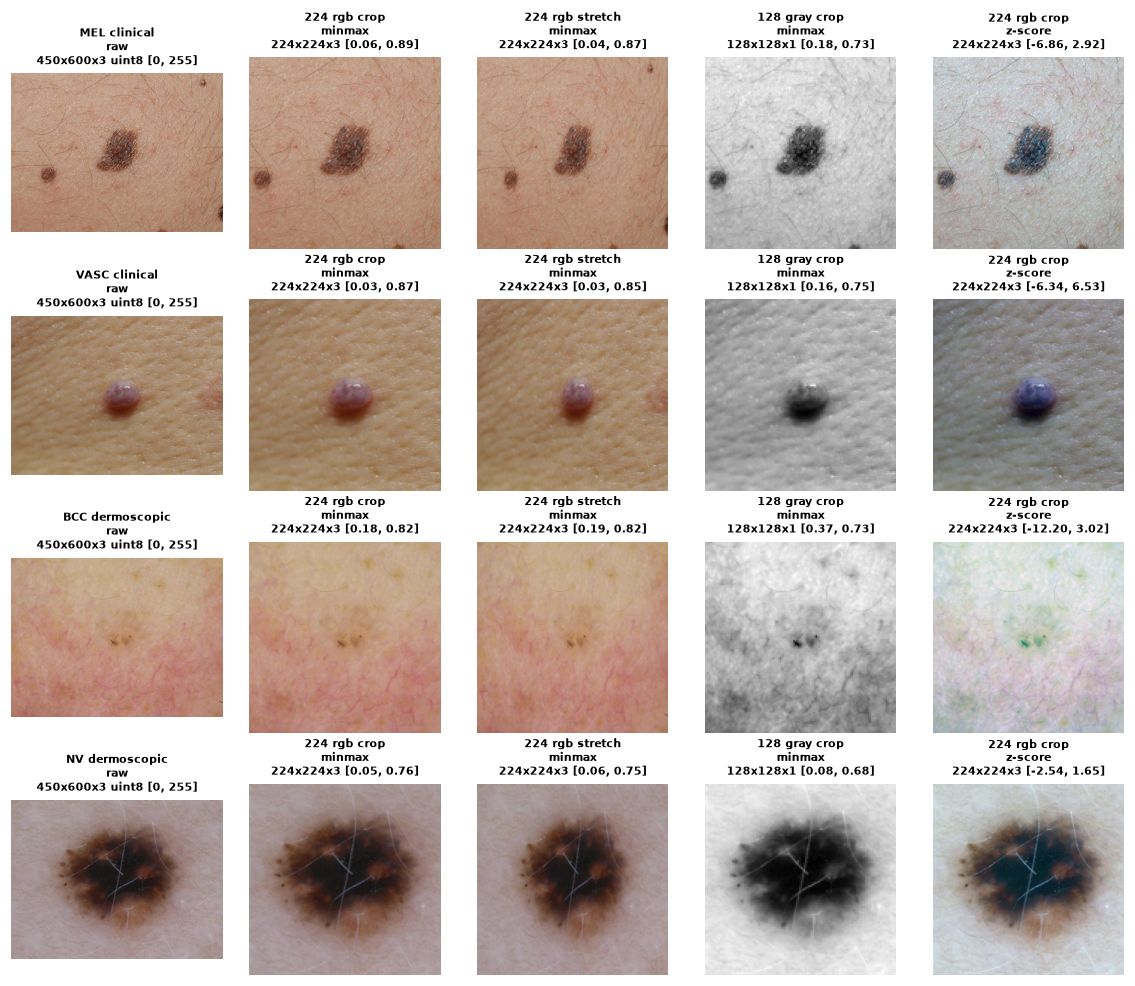

In [ ]:
demo = images.groupby("label").head(1).sort_values("label")            # one image of a few classes
demo = demo[demo.label.isin(["MEL", "BCC", "NV", "VASC"])].sort_values("image_type")
configs = {
    "224 rgb crop\nminmax": PreprocessConfig(size=(224, 224)),
    "224 rgb stretch\nminmax": PreprocessConfig(size=(224, 224), resize_mode="stretch"),
    "128 gray crop\nminmax": PreprocessConfig(size=(128, 128), color_mode="gray"),
    "224 rgb crop\nz-score": PreprocessConfig(size=(224, 224), normalize="zscore"),
}
viz.plot_before_after(list(demo.path), configs, labels=[f"{l} {t}" for l, t in zip(demo.label, demo.image_type)],
                      save=FIG / "11_before_after.png");

In [ ]:
arr, info = preprocess_image(demo.path.iloc[0])
print("array:", arr.shape, arr.dtype, "| range [%.3f, %.3f]" % (arr.min(), arr.max()))
info.as_dict()

array: (224, 224, 3) float32 | range [0.059, 0.890]


{'source': '/Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k/images/ISIC_0082447.jpg',
 'input_shape': (450, 600, 3),
 'output_shape': (224, 224, 3),
 'dtype': 'float32',
 'value_min': 0.05882352963089943,
 'value_max': 0.8901960849761963,
 'value_mean': 0.5796270966529846,
 'value_std': 0.12304216623306274,
 'steps': ['resize[crop]->224x224', 'rgb', 'minmax(/255)->[0,1]']}

In [ ]:
# batch with two deliberately bad entries: a path that does not exist, and a non-image file
bad = {"MISSING_FILE": milk10k.IMAGE_DIR / "ISIC_0000000.jpg", "NOT_AN_IMAGE": milk10k.DATA_DIR / "attribution.txt"}
items = {**dict(zip(demo.isic_id, demo.path)), **bad}
res = preprocess_batch(items, PreprocessConfig(size=(128, 128)))
print("stacked:", res.images.shape, res.images.dtype, "| kept:", res.ids)
print("skipped:")
for i, why in res.skipped:
    print("  ", i, "->", why)

stacked: (4, 128, 128, 3) float32 | kept: ['ISIC_0082447', 'ISIC_0091477', 'ISIC_0076255', 'ISIC_0073863']
skipped:
   MISSING_FILE -> FileNotFoundError: image file not found: /Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k/images/ISIC_0000000.jpg
   NOT_AN_IMAGE -> UnidentifiedImageError: cannot identify image file '/Users/joshuacole/Desktop/School/AI/School/Computer Vision & Speech Recognition/data/raw/milk10k/attribution.txt'


## Part 4 — Data loader

```python
loader = MILK10kLoader(df, config, batch_size=32, shuffle=True, seed=0,
                       label_col="label", classes=None, image_dir=None, drop_last=False)
```
* **construct with** a metadata DataFrame with `isic_id`, `path` and a label column (e.g. `load_images_table()`,
  or any filtered subset — one modality, a train split, …) plus a `PreprocessConfig`.
* **at construction** rows with a missing label or **no image file on disk** are dropped (`loader.n_unavailable`),
  labels are encoded as integers in `CLASS_CODES` order (`loader.classes`, `loader.class_to_index`).
* **`len(loader)`** = batches per epoch; **`for batch in loader`** processes images on the fly (nothing is
  pre-loaded) and yields `Batch(images (B,H,W,C) float32, labels (B,) int64, ids, skipped, classes)`;
  `batch.label_names` maps the integers back. A file that fails mid-epoch is skipped and listed in `batch.skipped`
  with images and labels staying aligned.
* `loader.class_counts()` gives the per-class image counts of the available data; `shuffle=True` reshuffles every epoch.

In [ ]:
cfg = PreprocessConfig(size=(128, 128))
loader = MILK10kLoader(images, cfg, batch_size=32, shuffle=True, seed=0)
print(loader)
print("classes:", loader.classes)
t0 = time.time(); batch = next(iter(loader)); dt = time.time() - t0
print(f"first batch in {dt:.2f}s -> images {batch.images.shape} {batch.images.dtype}, labels {batch.labels.shape} {batch.labels.dtype}")
print("labels:", batch.labels[:12], "->", batch.label_names[:12])
print("ids   :", batch.ids[:4], "| skipped:", batch.skipped)

MILK10kLoader(n_images=10480, batches=328, batch_size=32, classes=11, shape=(128, 128, 3), unavailable=0)
classes: ['AKIEC', 'BCC', 'BEN_OTH', 'BKL', 'DF', 'INF', 'MAL_OTH', 'MEL', 'NV', 'SCCKA', 'VASC']
first batch in 0.05s -> images (32, 128, 128, 3) float32, labels (32,) int64
labels: [9 3 8 1 3 1 1 1 1 3 1 9] -> ['SCCKA', 'BKL', 'NV', 'BCC', 'BKL', 'BCC', 'BCC', 'BCC', 'BCC', 'BKL', 'BCC', 'SCCKA']
ids   : ['ISIC_6467881', 'ISIC_4146599', 'ISIC_8646399', 'ISIC_8951479'] | skipped: []


In [ ]:
# the "available subset" idea: drop half the rows' files (in the table only) and hand the loader a table that
# includes rows with no image on disk -> they are filtered out, not crashed on
fake = images.head(8).copy()
fake.loc[fake.index[:3], "path"] = fake.loc[fake.index[:3], "path"].map(lambda p: p.with_name("ISIC_missing.jpg"))
l2 = MILK10kLoader(fake, cfg, batch_size=8, shuffle=False)
print(l2, "| n_unavailable =", l2.n_unavailable)
# per-modality loaders come for free by filtering the table first
derm_loader = MILK10kLoader(images[images.image_type == "dermoscopic"], cfg, batch_size=64, seed=1)
print(derm_loader)

MILK10kLoader(n_images=5, batches=1, batch_size=8, classes=3, shape=(128, 128, 3), unavailable=3) | n_unavailable = 3


MILK10kLoader(n_images=5240, batches=82, batch_size=64, classes=11, shape=(128, 128, 3), unavailable=0)


## Part 5 — Data visualiser
Three utilities in `milk10k.viz`: `show_image_grid`, `plot_class_balance`, `plot_batch_summary`.
### 15. Sanity-check what the loader is producing

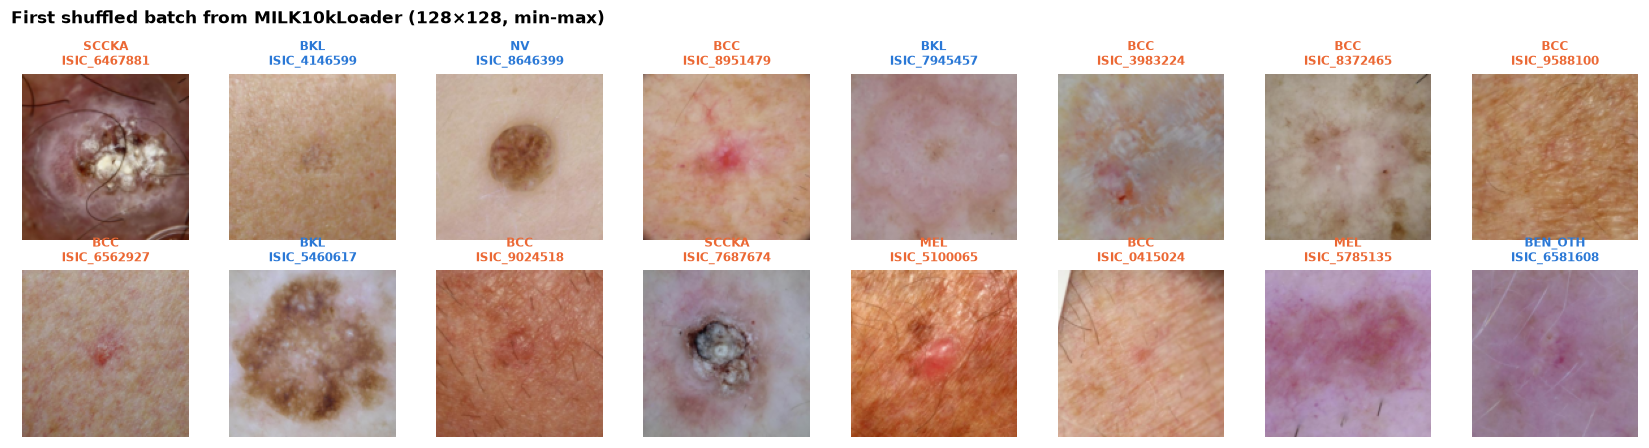

In [ ]:
viz.show_image_grid(batch, ncols=8, max_images=16, title="First shuffled batch from MILK10kLoader (128×128, min-max)",
                    save=FIG / "12_loader_batch_grid.png");

### 16. Class balance in the available data

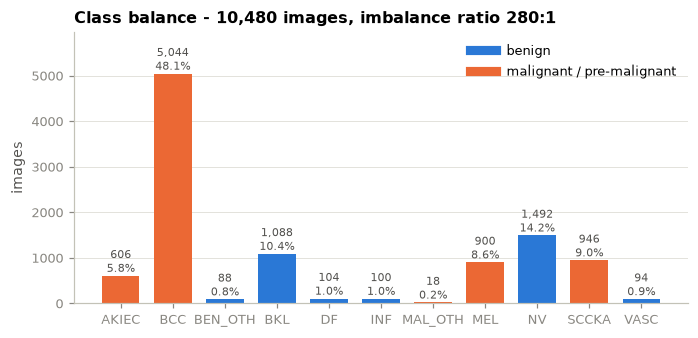

images per class: {'AKIEC': 606, 'BCC': 5044, 'BEN_OTH': 88, 'BKL': 1088, 'DF': 104, 'INF': 100, 'MAL_OTH': 18, 'MEL': 900, 'NV': 1492, 'SCCKA': 946, 'VASC': 94}
largest / smallest = 5044/18 = 280:1 ; malignant share = 71.7%


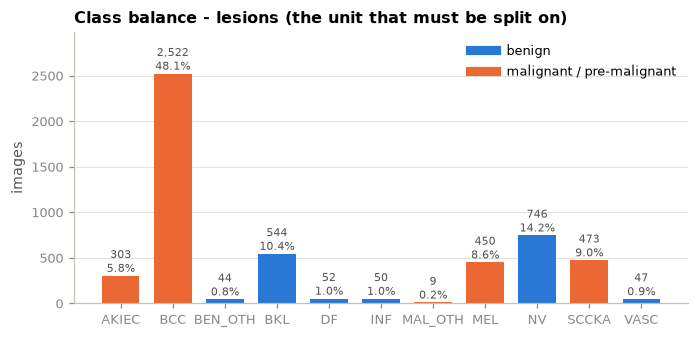

In [ ]:
viz.plot_class_balance(loader, save=FIG / "12_class_balance_images.png"); plt.show()
viz.plot_class_balance(lesions, title="Class balance - lesions (the unit that must be split on)",
                       save=FIG / "12_class_balance_lesions.png");
counts = loader.class_counts()
print("images per class:", counts.to_dict())
print(f"largest / smallest = {counts.max()}/{counts.min()} = {counts.max()/counts.min():.0f}:1 ; "
      f"malignant share = {images.malignant.mean():.1%}")

### 17. Pipeline debugging view — did normalisation do what the config says?

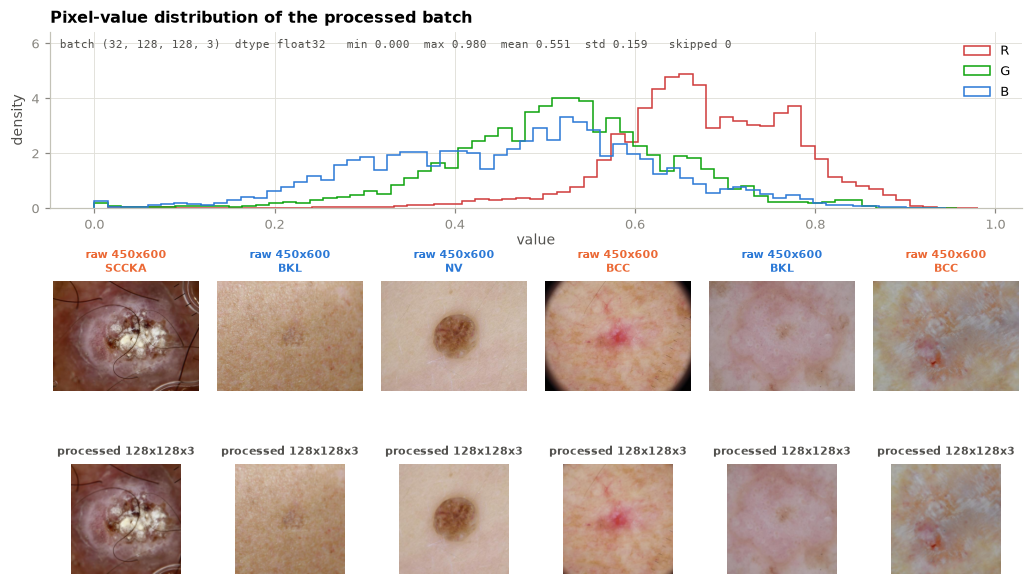

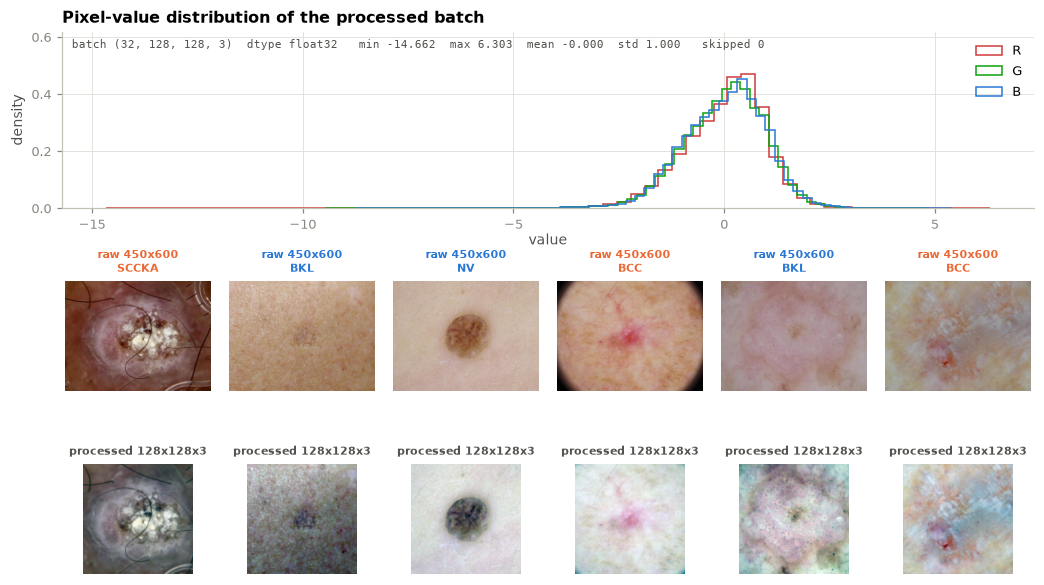

In [ ]:
viz.plot_batch_summary(batch, n_examples=6, save=FIG / "12_batch_summary_minmax.png"); plt.show()
z_loader = MILK10kLoader(images, PreprocessConfig(size=(128, 128), normalize="zscore"), batch_size=32, seed=0)
viz.plot_batch_summary(next(iter(z_loader)), n_examples=6, save=FIG / "12_batch_summary_zscore.png");

**Class balance (task 16).** The available data is the full 10,480 images / 5,240 lesions. It is **severely imbalanced**: BCC alone is 48 % of the images (5,044) while MAL_OTH has 18 images (9 lesions) — a **280 : 1** ratio between the largest and smallest class; five classes (MAL_OTH, BEN_OTH, VASC, INF, DF) have ≤ 104 images each, and 72 % of lesions are malignant. Consequences for later milestones: split **by lesion** (both images of a lesion in the same fold) and stratify by class; use class-weighted loss, re-sampling or a merged "other" bucket for the five tail classes; never report plain accuracy — a model that always says BCC gets 48 % — but macro-F1 / balanced accuracy and per-class sensitivity, especially for MEL and the rare malignant classes. The loader's `class_counts()` gives exactly the weights needed for a weighted sampler.

**Batch summary (task 17).** The two summaries confirm the pipeline does what the config says: the min-max batch lies in [0.0, 1.0] with mean ≈ 0.55 (skin is bright), the z-score batch has mean 0.000 and std 1.000 with a long negative tail from dark pigment; the raw-vs-processed strip shows the centre crop keeps the lesion in frame at 128×128.

## Design notes (Parts 3–5)

* **One config object, one processing path.** `PreprocessConfig` is an immutable dataclass validated at construction, so an invalid combination fails immediately instead of three batches in. `preprocess_image` is the single place pixels are decoded / resized / normalised: the colour analysis (Part 2), the batch function, the loader and the visualiser all call it, so a change (e.g. switching to dataset-level z-score for training) happens once. Every call returns an `ImageInfo` (input / output shape, dtype, value range, steps applied) so an array is never a mystery.
* **Failures are data, not exceptions.** `preprocess_batch` catches per-item errors and returns `skipped = [(id, reason)]` alongside the stacked array; the loader forwards that per batch, and `available_subset` removes rows with no file *before* iteration. A corrupt file costs one log line, not an epoch.
* **Loader = table + config + batch size.** Because it takes any DataFrame with `isic_id / path / label`, the same class serves a dermoscopic-only loader, a train / val split or a debugging subset by filtering the table first — no flags to add later. It is lazy (nothing is loaded until iteration), reproducible (`seed`) and yields a small `Batch` dataclass rather than a tuple so fields are named.
* **Visualiser accepts what the loader emits.** `show_image_grid` and `plot_batch_summary` take a `Batch` directly (or plain arrays / paths), and `plot_class_balance` takes a DataFrame or a loader, so the sanity check is one line after constructing a loader. Colour encodes benign vs malignant only; eleven classes are identified by position, not by eleven hues.

Everything is covered by `tests/` (32 pytest cases on synthetic images plus real MILK10k files): `python -m pytest tests -q`.